# **1. CALIDAD DE DATOS**


**Nombre del dataset:** Predicción de la pérdida de clientes bancarios (Bank Customer Churn Prediction)

**Información:** El conjunto de datos de abandono de clientes bancarios se utiliza comúnmente para predecir la pérdida de clientes en el sector bancario. Contiene información sobre los clientes que dejaron la entidad o que siguen siendo clientes.

El conjunto de datos incluye las siguientes variables:

1. ID del cliente: Un identificador único para cada cliente
2. Apellido: El apellido del cliente
3. Puntuación crediticia: Un valor numérico que representa la puntuación crediticia del cliente
4. Geografía: El país de residencia del cliente (Francia, España o Alemania)
5. Sexo: El sexo del cliente (masculino o femenino)
6. Edad: La edad del cliente
7. Antigüedad: Años que el cliente lleva en el banco.
8. Saldo: Saldo de la cuenta del cliente.
9. Número de productos: Número de productos bancarios que utiliza el cliente (p. ej., cuenta de ahorros, tarjeta de crédito).
10. Tiene tarjeta de crédito: Si el cliente tiene tarjeta de crédito (1 = sí, 0 = no).
11. Miembro activo: Si el cliente es miembro activo (1 = sí, 0 = no).
12. Salario estimado: Salario estimado del cliente.
13. Salida: Si el cliente se ha dado de baja (1 = sí, 0 = no).

El conjunto de datos almacena 10000 registros.
Enlace: https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction

#1.1. Perfilamiento de datos

In [114]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [115]:
# Se cargan los datos (Esta alojado en el repositorio)
data= pd.read_csv("Churn_Modelling.csv")
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,3,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,4,15701354,Boni,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [116]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9998 non-null   int64  
 1   CustomerId       9998 non-null   int64  
 2   Surname          9998 non-null   object 
 3   CreditScore      9998 non-null   int64  
 4   Geography        9997 non-null   object 
 5   Gender           9998 non-null   object 
 6   Age              9997 non-null   float64
 7   Tenure           9998 non-null   int64  
 8   Balance          9998 non-null   float64
 9   NumOfProducts    9998 non-null   int64  
 10  HasCrCard        9997 non-null   float64
 11  IsActiveMember   9997 non-null   float64
 12  EstimatedSalary  9998 non-null   float64
 13  Exited           9998 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB


In [117]:
#Corrección del tipo de datos object a categorías
data['Surname'] = data['Surname'].astype('category')
data['Geography'] = data['Geography'].astype('category')
data['Gender'] = data['Gender'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        9998 non-null   int64   
 1   CustomerId       9998 non-null   int64   
 2   Surname          9998 non-null   category
 3   CreditScore      9998 non-null   int64   
 4   Geography        9997 non-null   category
 5   Gender           9998 non-null   category
 6   Age              9997 non-null   float64 
 7   Tenure           9998 non-null   int64   
 8   Balance          9998 non-null   float64 
 9   NumOfProducts    9998 non-null   int64   
 10  HasCrCard        9997 non-null   float64 
 11  IsActiveMember   9997 non-null   float64 
 12  EstimatedSalary  9998 non-null   float64 
 13  Exited           9998 non-null   int64   
dtypes: category(3), float64(5), int64(6)
memory usage: 986.1 KB


In [118]:
#Instalar pandas profiling
!pip install ydata-profiling

In [119]:
# Cargar librería para Profiling
from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=False) # minimal=True
profile_data

Output hidden; open in https://colab.research.google.com to view.

In [120]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output_Churn_Modelling.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#1.2. Dimensiones de la Calidad de Datos

**Completitud:** ¿Está toda la información disponible? ¿Hay datos faltantes o ausentes?

**Exactitud:** ¿La información es correcta y libre de error?

**Conformidad:** ¿Los valores de los datos están conformes con los formatos esperados? Ejemplo: Una fecha en formato AAAA/MM/DD cuando debería ser DD/MM/AAAA.

**Oportunidad:** ¿La información llega cuando se necesita?

**Duplicidad:** ¿Existen múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos?

**Integridad:** ¿Faltan datos relacionados importantes? ¿Es clara la conectividad y las relaciones con otros datos?

# **Diagnóstico de las dimensiones según el perfilado:**
1. Completitud:  De acuerdo con el perfilado, el dataset contiene un 0.1% de valores nulos en la columna Geography, Age, HasCrCard y IsActiveMember.
2. Exactitud: Se detecto registros con tipo Categorical en columna que debería ser string (Surname). Tambien, se detectaron columnas de tipo numericas que deberían ser Categorical (Tenure, NumOfProducts, HasCrCard, IsActiveMember y Exited). Cabe aclarar que el formato HTML indica que son Categorical, pero pandas las detecta como numericas.
3. Conformidad: Cumple con lo requerido.
4. Oportunidad: Actualizados
5. Duplicidad: Hay registros duplicados en las variables RowNumber, CustomerID
6. Integridad: Cumple con lo requerido.

#1.3. Limpieza de los Datos

1. Detección de duplicados
2. Selección de datos
3. Limpieza de atípicos
4. Limpieza de nulos


In [121]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9998 entries, 0 to 9997
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        9998 non-null   int64   
 1   CustomerId       9998 non-null   int64   
 2   Surname          9998 non-null   category
 3   CreditScore      9998 non-null   int64   
 4   Geography        9997 non-null   category
 5   Gender           9998 non-null   category
 6   Age              9997 non-null   float64 
 7   Tenure           9998 non-null   int64   
 8   Balance          9998 non-null   float64 
 9   NumOfProducts    9998 non-null   int64   
 10  HasCrCard        9997 non-null   float64 
 11  IsActiveMember   9997 non-null   float64 
 12  EstimatedSalary  9998 non-null   float64 
 13  Exited           9998 non-null   int64   
dtypes: category(3), float64(5), int64(6)
memory usage: 986.1 KB


**1. Detección de duplicados**

In [122]:
#Sólo dejamos el CustomerID mas reciente
data.drop_duplicates(subset=['RowNumber'], keep='last', inplace=True)
data.drop_duplicates(subset=['CustomerId'], keep='last', inplace=True)
#data=data.drop_duplicates(subset=['ID'], keep='last')

In [123]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9997
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        9996 non-null   int64   
 1   CustomerId       9996 non-null   int64   
 2   Surname          9996 non-null   category
 3   CreditScore      9996 non-null   int64   
 4   Geography        9995 non-null   category
 5   Gender           9996 non-null   category
 6   Age              9995 non-null   float64 
 7   Tenure           9996 non-null   int64   
 8   Balance          9996 non-null   float64 
 9   NumOfProducts    9996 non-null   int64   
 10  HasCrCard        9995 non-null   float64 
 11  IsActiveMember   9995 non-null   float64 
 12  EstimatedSalary  9996 non-null   float64 
 13  Exited           9996 non-null   int64   
dtypes: category(3), float64(5), int64(6)
memory usage: 1.0 MB


**2. Selección de Datos**

In [124]:
# Variables irrelevantes para el proceso de minería de Datos
data = data.drop('RowNumber',axis=1) #Eliminamos el RowNumber por ser irrelevante, axis=1 indica que es una columna
data = data.drop('CustomerId',axis=1) #Eliminamos el ID por ser irrelevante, axis=1 indica que es una columna
data = data.drop('Surname',axis=1) #Eliminamos el Surname por ser irrelevante, axis=1 indica que es una columna

# Modificar variables que deberian ser Categoricas
data['Tenure'] = data['Tenure'].astype('category')
data['NumOfProducts'] = data['NumOfProducts'].astype('category')
data['HasCrCard'] = data['HasCrCard'].astype('category')
data['IsActiveMember'] = data['IsActiveMember'].astype('category')
data['Exited'] = data['Exited'].astype('category')
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [125]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9997
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      9996 non-null   int64   
 1   Geography        9995 non-null   category
 2   Gender           9996 non-null   category
 3   Age              9995 non-null   float64 
 4   Tenure           9996 non-null   category
 5   Balance          9996 non-null   float64 
 6   NumOfProducts    9996 non-null   category
 7   HasCrCard        9995 non-null   category
 8   IsActiveMember   9995 non-null   category
 9   EstimatedSalary  9996 non-null   float64 
 10  Exited           9996 non-null   category
dtypes: category(7), float64(3), int64(1)
memory usage: 460.0 KB


Graficas estadisticas de los datos

**3. Limpieza de datos atípicos: se asigna nulo**

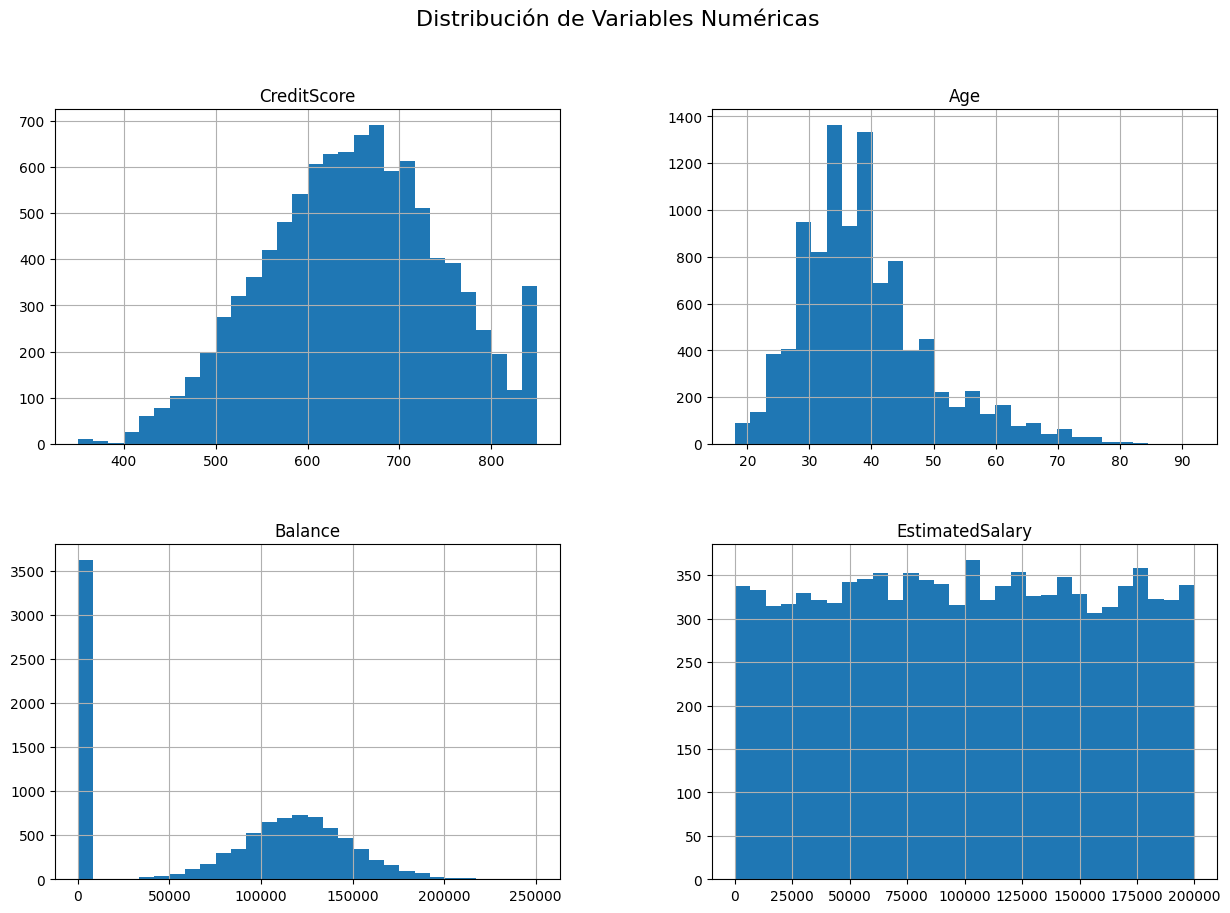

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generar histogramas para todas las variables numéricas
data.hist(figsize=(15, 10), bins=30)
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.show()

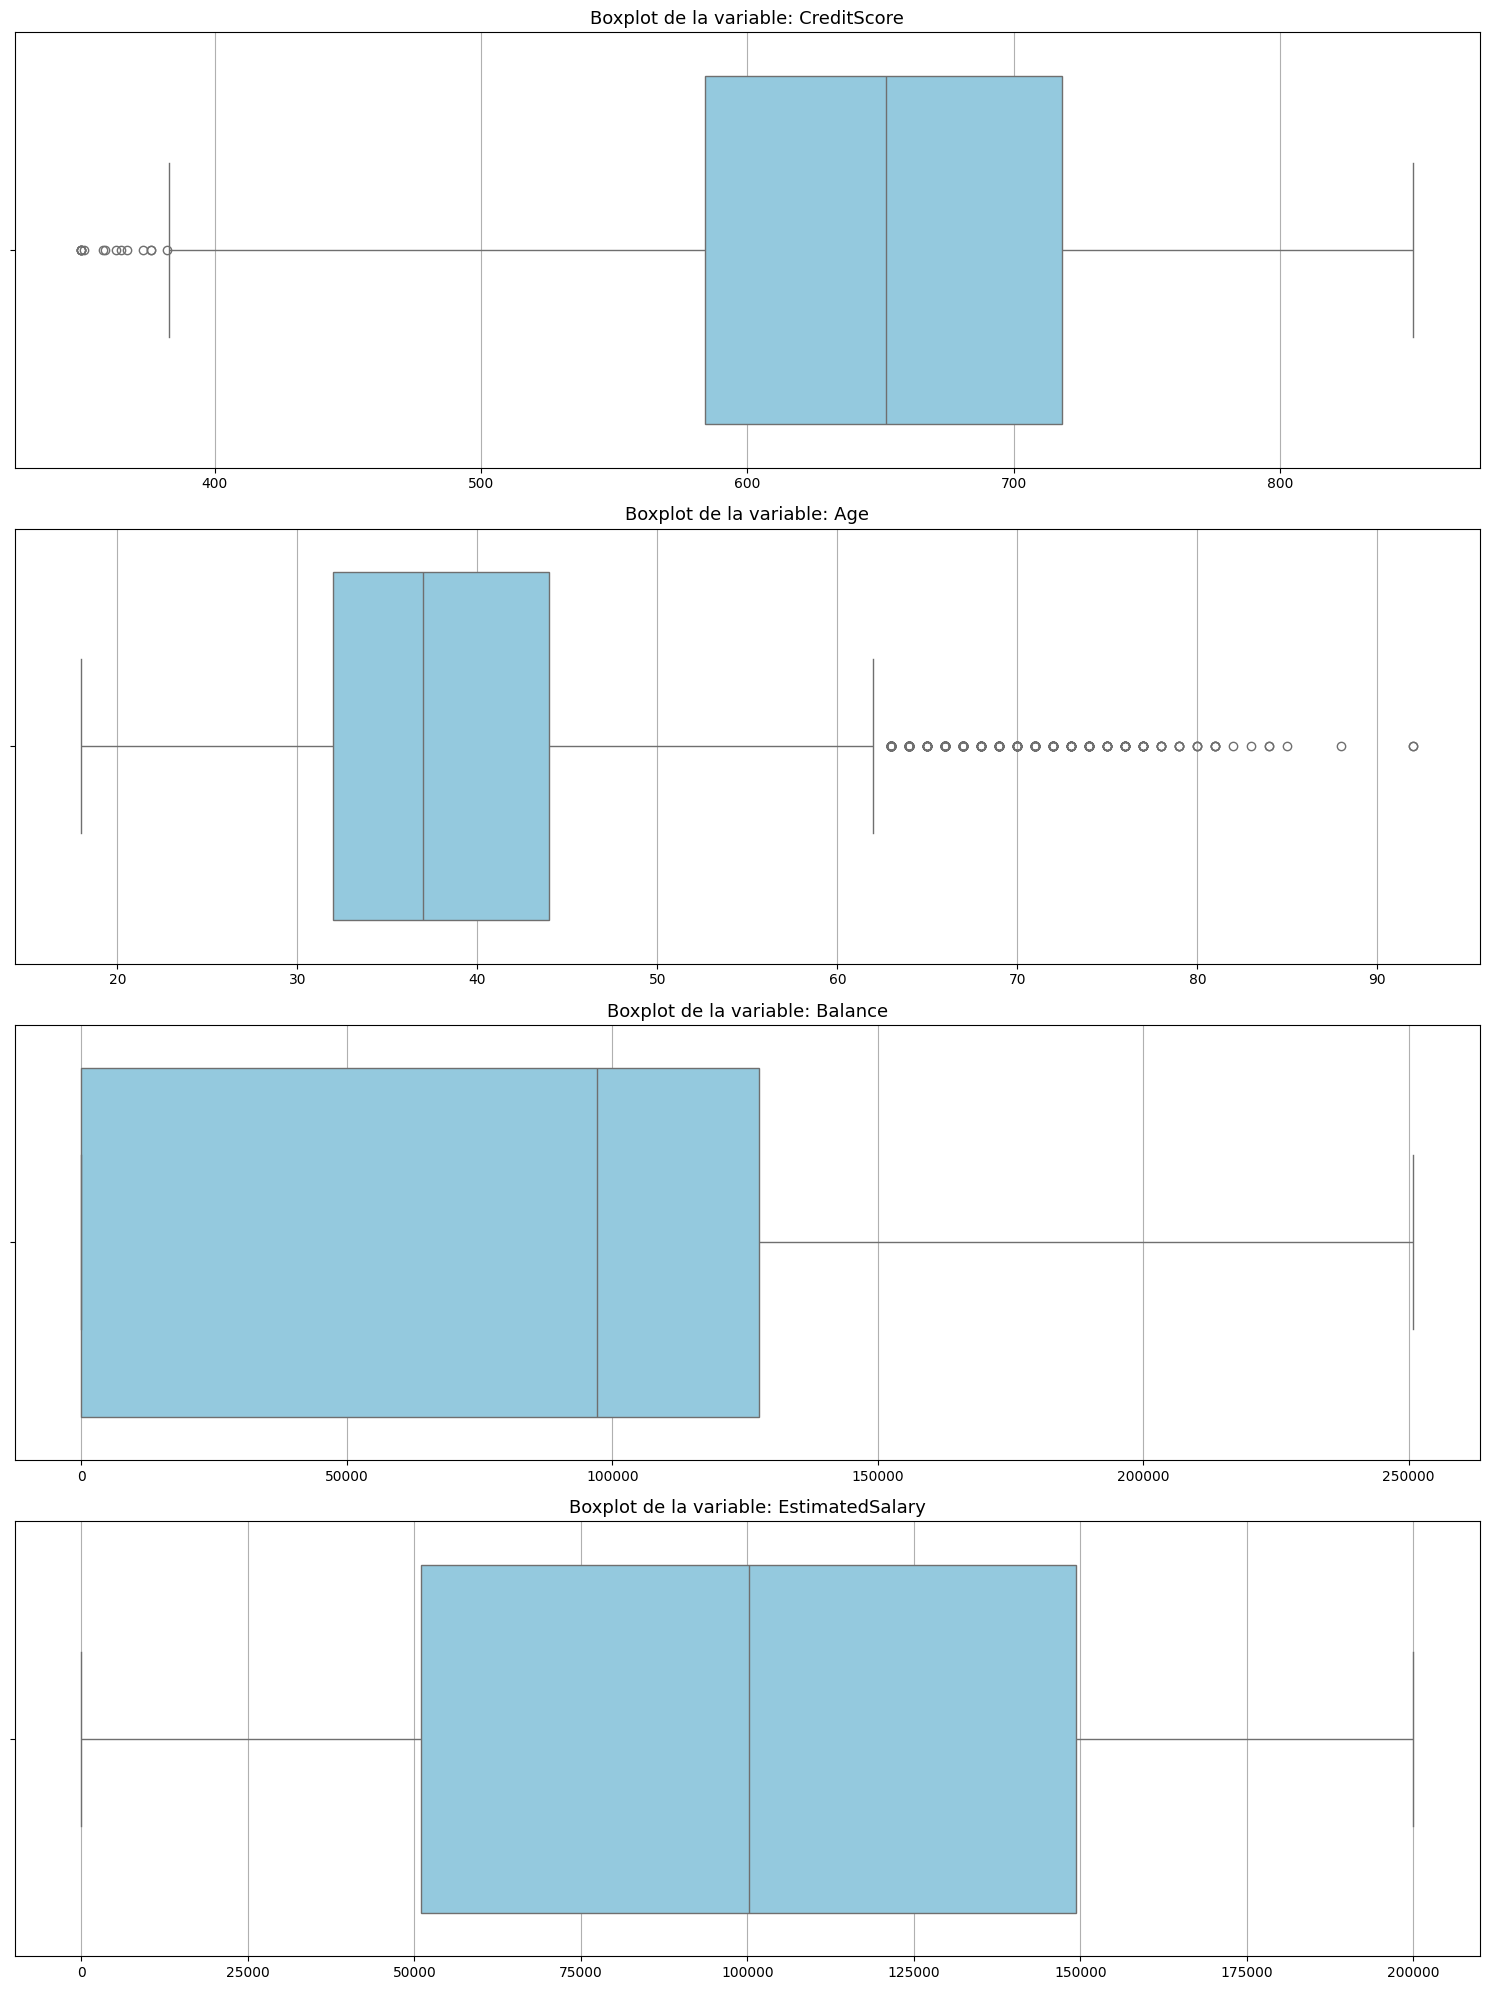

In [127]:
# Seleccionar solo las columnas numéricas
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Definir tamaño del lienzo (uno por variable)
plt.figure(figsize=(15, 5 * len(num_cols)))

# Crear un boxplot para cada variable numérica
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=data[col], color='skyblue')
    plt.title(f"Boxplot de la variable: {col}", fontsize=13)
    plt.xlabel("")
    plt.grid(True, axis='x')

plt.tight_layout()
plt.show()

/tmp/ipython-input-873738938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette="pastel")
/tmp/ipython-input-873738938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette="pastel")
/tmp/ipython-input-873738938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=data, palette="pastel")
/tmp/ipython-input-873738938.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `lege

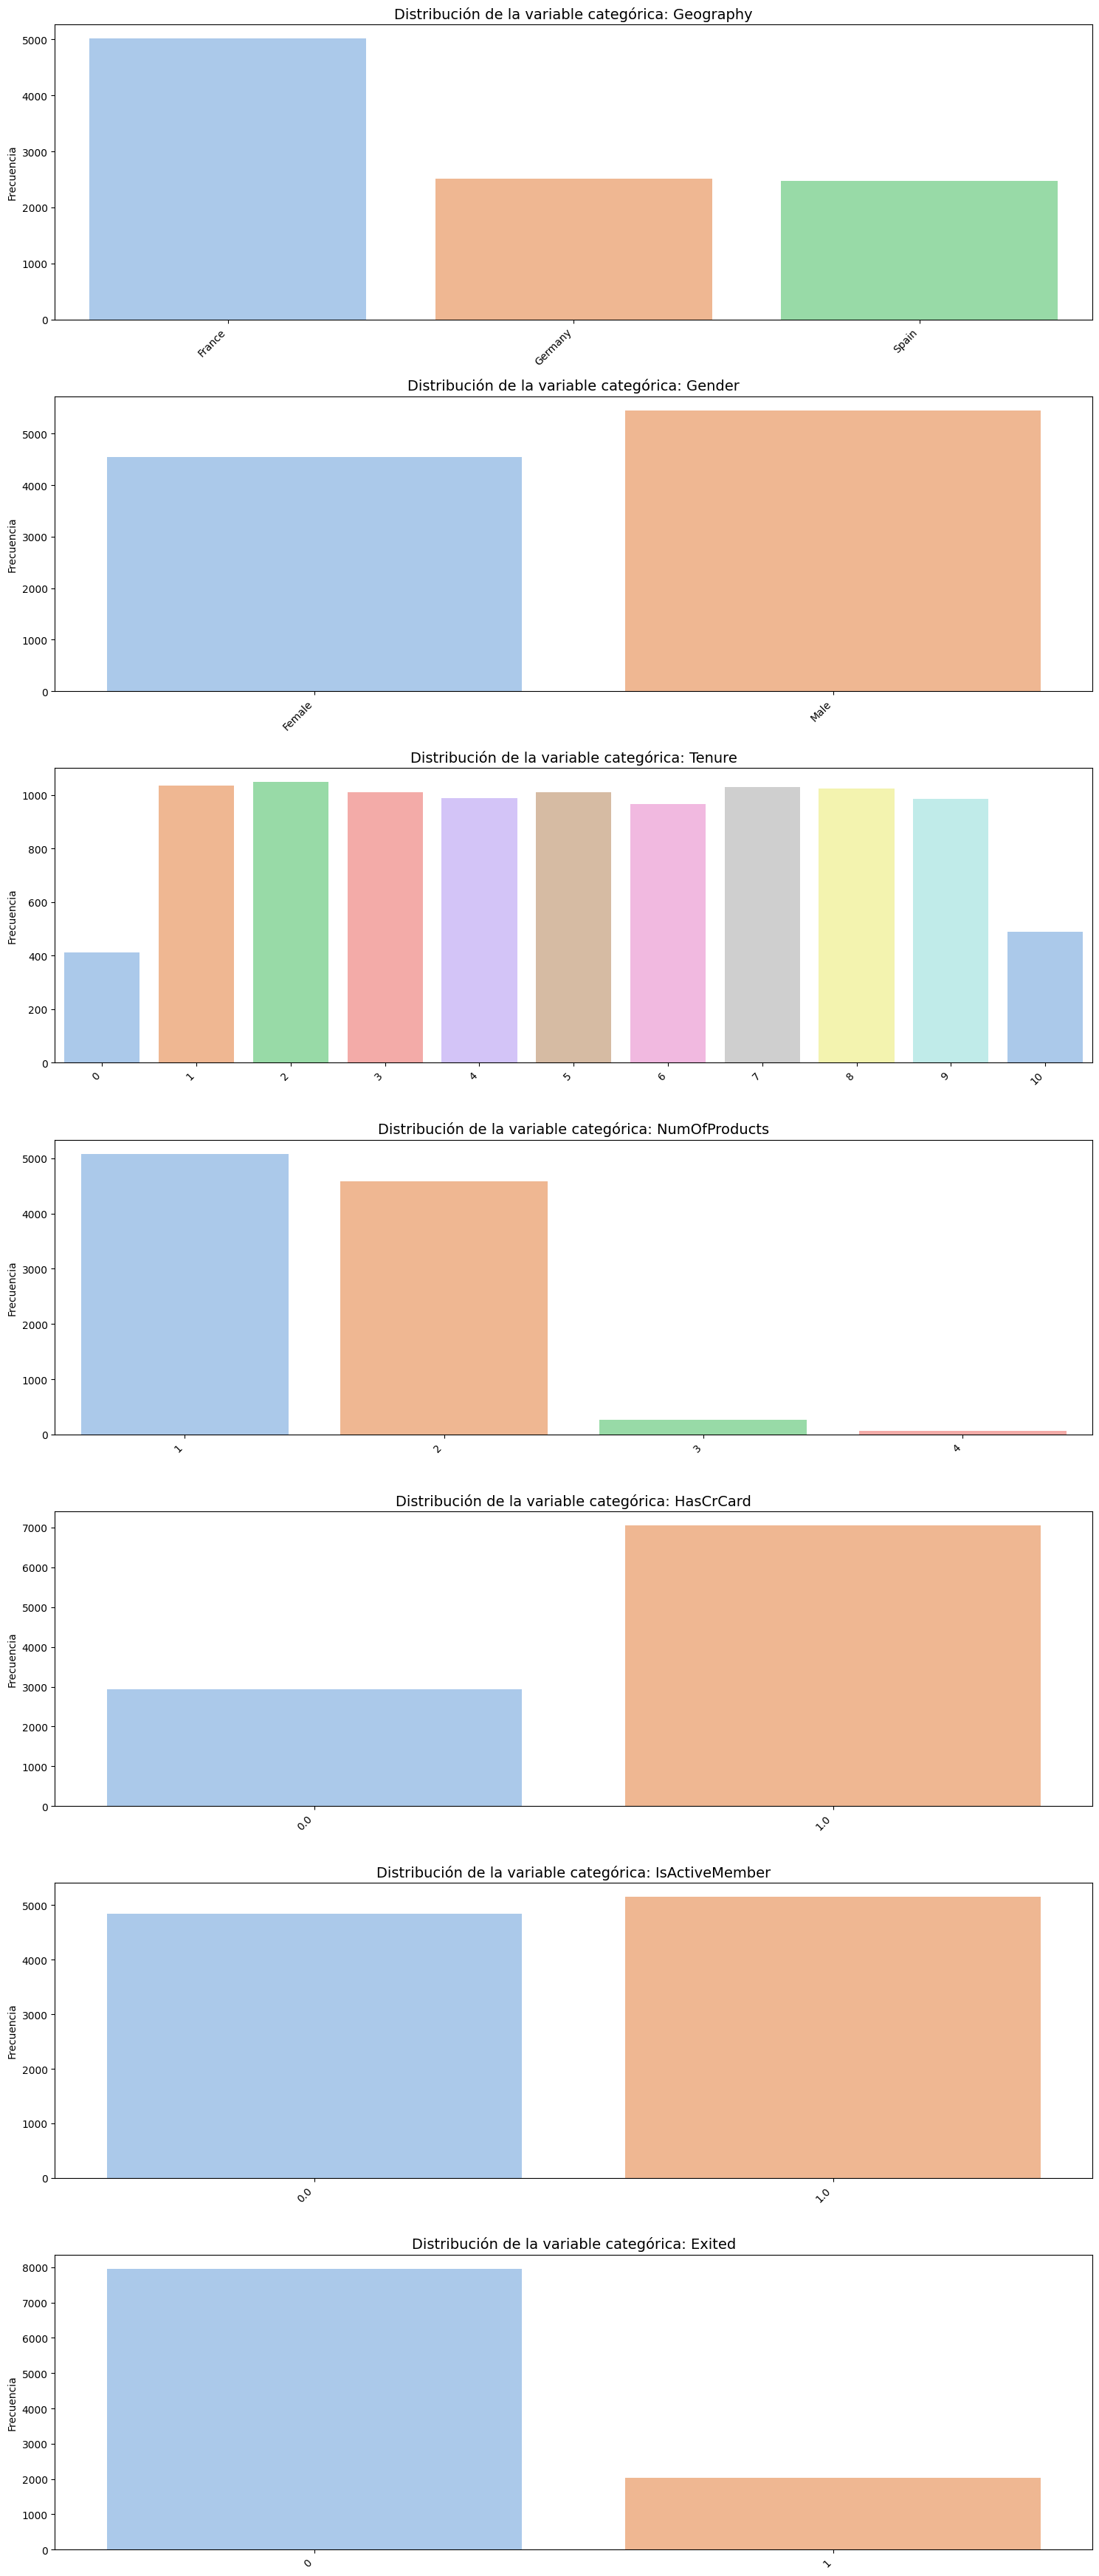

In [128]:
# Seleccionar las columnas categóricas
cat_cols = data.select_dtypes(include=['category']).columns

# Definir tamaño general de las figuras
plt.figure(figsize=(15, 5 * len(cat_cols)))

# Graficar cada variable categórica
for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    sns.countplot(x=col, data=data, palette="pastel")
    plt.title(f"Distribución de la variable categórica: {col}", fontsize=14)
    plt.xlabel("")
    plt.ylabel("Frecuencia")
    plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [129]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,608,Spain,Female,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,502,France,Female,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,699,France,Female,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,850,Spain,Female,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [130]:
#Modificar 1 y 0 por Si y No en las variables HasCrCard, IsActiveMember y Exited para una mejor Comprensión
data[['HasCrCard', 'IsActiveMember', 'Exited']] = data[['HasCrCard', 'IsActiveMember', 'Exited']].replace({0: 'No', 1: 'Si'})
data.head()

/tmp/ipython-input-2351315565.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data[['HasCrCard', 'IsActiveMember', 'Exited']] = data[['HasCrCard', 'IsActiveMember', 'Exited']].replace({0: 'No', 1: 'Si'})
/tmp/ipython-input-2351315565.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data[['HasCrCard', 'IsActiveMember', 'Exited']] = data[['HasCrCard', 'IsActiveMember', 'Exited']].replace({0: 'No', 1: 'Si'})
/tmp/ipython-input-2351315565.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.0,2,0.00,1,Si,Si,101348.88,Si
1,608,Spain,Female,41.0,1,83807.86,1,No,Si,112542.58,No
2,502,France,Female,42.0,8,159660.80,3,Si,No,113931.57,Si
3,699,France,Female,39.0,1,0.00,2,No,No,93826.63,No
4,850,Spain,Female,43.0,2,125510.82,1,NaN,Si,79084.10,No


In [131]:
# De acuerdo al análisis de las gráficas anteriores, se determina que no hay datos atípicos

**4. Limpieza de datos nulos: Imputación**

In [132]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9997
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      9996 non-null   int64   
 1   Geography        9995 non-null   category
 2   Gender           9996 non-null   category
 3   Age              9995 non-null   float64 
 4   Tenure           9996 non-null   category
 5   Balance          9996 non-null   float64 
 6   NumOfProducts    9996 non-null   category
 7   HasCrCard        9995 non-null   category
 8   IsActiveMember   9995 non-null   category
 9   EstimatedSalary  9996 non-null   float64 
 10  Exited           9996 non-null   category
dtypes: category(7), float64(3), int64(1)
memory usage: 460.0 KB


In [133]:
#Limpieza de datos nulos: Imputación por la media y moda
from sklearn.impute import SimpleImputer

#Imputacion de variables numéricas: media
ImpNumeros = SimpleImputer(missing_values=np.nan, strategy='mean')
data[['Age']] = ImpNumeros.fit_transform(data[['Age']])

#Imputacion de variables categóricas: moda
ImpCategorias = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
data[['Geography', 'HasCrCard', 'IsActiveMember']] = ImpCategorias.fit_transform(data[['Geography', 'HasCrCard', 'IsActiveMember']])

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9997
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      9996 non-null   int64   
 1   Geography        9996 non-null   object  
 2   Gender           9996 non-null   category
 3   Age              9996 non-null   float64 
 4   Tenure           9996 non-null   category
 5   Balance          9996 non-null   float64 
 6   NumOfProducts    9996 non-null   category
 7   HasCrCard        9996 non-null   object  
 8   IsActiveMember   9996 non-null   object  
 9   EstimatedSalary  9996 non-null   float64 
 10  Exited           9996 non-null   category
dtypes: category(4), float64(3), int64(1), object(3)
memory usage: 664.6+ KB


In [134]:
#Valores de la imputación
print(ImpNumeros.statistics_)
print(ImpCategorias.statistics_)

[38.92076338]
['France' 'Si' 'Si']


In [135]:
# Corregir datos de nuevo
data['Geography'] = data['Geography'].astype('category')
data['HasCrCard'] = data['HasCrCard'].astype('category')
data['IsActiveMember'] = data['IsActiveMember'].astype('category')
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9997
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   CreditScore      9996 non-null   int64   
 1   Geography        9996 non-null   category
 2   Gender           9996 non-null   category
 3   Age              9996 non-null   float64 
 4   Tenure           9996 non-null   category
 5   Balance          9996 non-null   float64 
 6   NumOfProducts    9996 non-null   category
 7   HasCrCard        9996 non-null   category
 8   IsActiveMember   9996 non-null   category
 9   EstimatedSalary  9996 non-null   float64 
 10  Exited           9996 non-null   category
dtypes: category(7), float64(3), int64(1)
memory usage: 460.0 KB


#1.4. Mejora de los Datos


In [136]:
# Todas las variables deben ser numéricas para calcular las correlaciones
# Se crean dummies para las variables categóricas

#Dummies para variable con más de 2 categorías
data_num = pd.get_dummies(data, columns=['Geography', 'Tenure', 'NumOfProducts' ], drop_first=False, dtype=int) #No se borra

#Dummies para variable con 2 categorías
data_num = pd.get_dummies(data_num, columns=['Gender', 'HasCrCard', 'IsActiveMember', 'Exited'],  drop_first=True, dtype=int)#Si se borra

In [137]:
#Correlaciones
data_num.corr()

,CreditScore,Age,Balance,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Tenure_0,Tenure_1,Tenure_2,...,Tenure_9,Tenure_10,NumOfProducts_1,NumOfProducts_2,NumOfProducts_3,NumOfProducts_4,Gender_Male,HasCrCard_Si,IsActiveMember_Si,Exited_Si
CreditScore,1.000000,-0.003515,0.006313,-0.001774,-0.009237,0.005572,0.005105,0.003250,-0.006063,0.008149,...,0.010624,0.007263,-0.014552,0.015559,-0.004150,0.002454,-0.002843,-0.005284,0.025641,-0.026758
Age,-0.003515,1.000000,0.028678,-0.006883,-0.038793,0.046952,-0.002215,0.005260,0.016473,0.004871,...,0.013387,0.004766,0.072723,-0.102501,0.067411,0.050121,-0.027253,-0.011984,0.085865,0.284921
Balance,0.006313,0.028678,1.000000,0.012548,-0.231254,0.400892,-0.134706,0.011275,0.011249,0.001916,...,0.000383,-0.009631,0.359977,-0.363594,-0.002735,0.021476,0.011663,-0.014845,-0.010161,0.118857
EstimatedSalary,-0.001774,-0.006883,0.012548,1.000000,-0.003387,0.009968,-0.006086,0.008248,0.002238,-0.010580,...,-0.003869,0.009944,-0.010321,0.005449,0.012158,0.006316,-0.008406,-0.009930,-0.011422,0.012531
Geography_France,-0.009237,-0.038793,-0.231254,-0.003387,1.000000,-0.580321,-0.575532,-0.002131,0.006532,-0.000374,...,0.007068,-0.002072,-0.014059,0.026347,-0.036549,-0.002824,0.006958,0.002597,0.003111,-0.104853
Geography_Germany,0.005572,0.046952,0.400892,0.009968,-0.580321,1.000000,-0.331995,0.001646,0.003349,0.009162,...,0.017208,0.004664,0.034245,-0.052067,0.041997,0.026747,-0.025083,0.010687,-0.020260,0.173846
Geography_Spain,0.005105,-0.002215,-0.134706,-0.006086,-0.575532,-0.331995,1.000000,0.000815,-0.010930,-0.008767,...,-0.025466,-0.002283,-0.018104,0.021767,0.000161,-0.023588,0.017129,-0.013740,0.016741,-0.053122
Tenure_0,0.003250,0.005260,0.011275,0.008248,-0.002131,0.001646,0.000815,1.000000,-0.070553,-0.071046,...,-0.068598,-0.047082,0.026130,-0.018681,-0.015586,-0.016132,-0.016538,-0.025813,0.006214,0.013579
Tenure_1,-0.006063,0.016473,0.011249,0.002238,0.006532,0.003349,-0.010930,-0.070553,1.000000,-0.116308,...,-0.112300,-0.077077,0.027389,-0.028957,0.009095,-0.009405,-0.005156,-0.021093,0.023428,0.017277
Tenure_2,0.008149,0.004871,0.001916,-0.010580,-0.000374,0.009162,-0.008767,-0.071046,-0.116308,1.000000,...,-0.113085,-0.077616,-0.039135,0.040689,-0.013976,0.019910,-0.002566,-0.001039,0.013042,-0.010102


<Axes: >

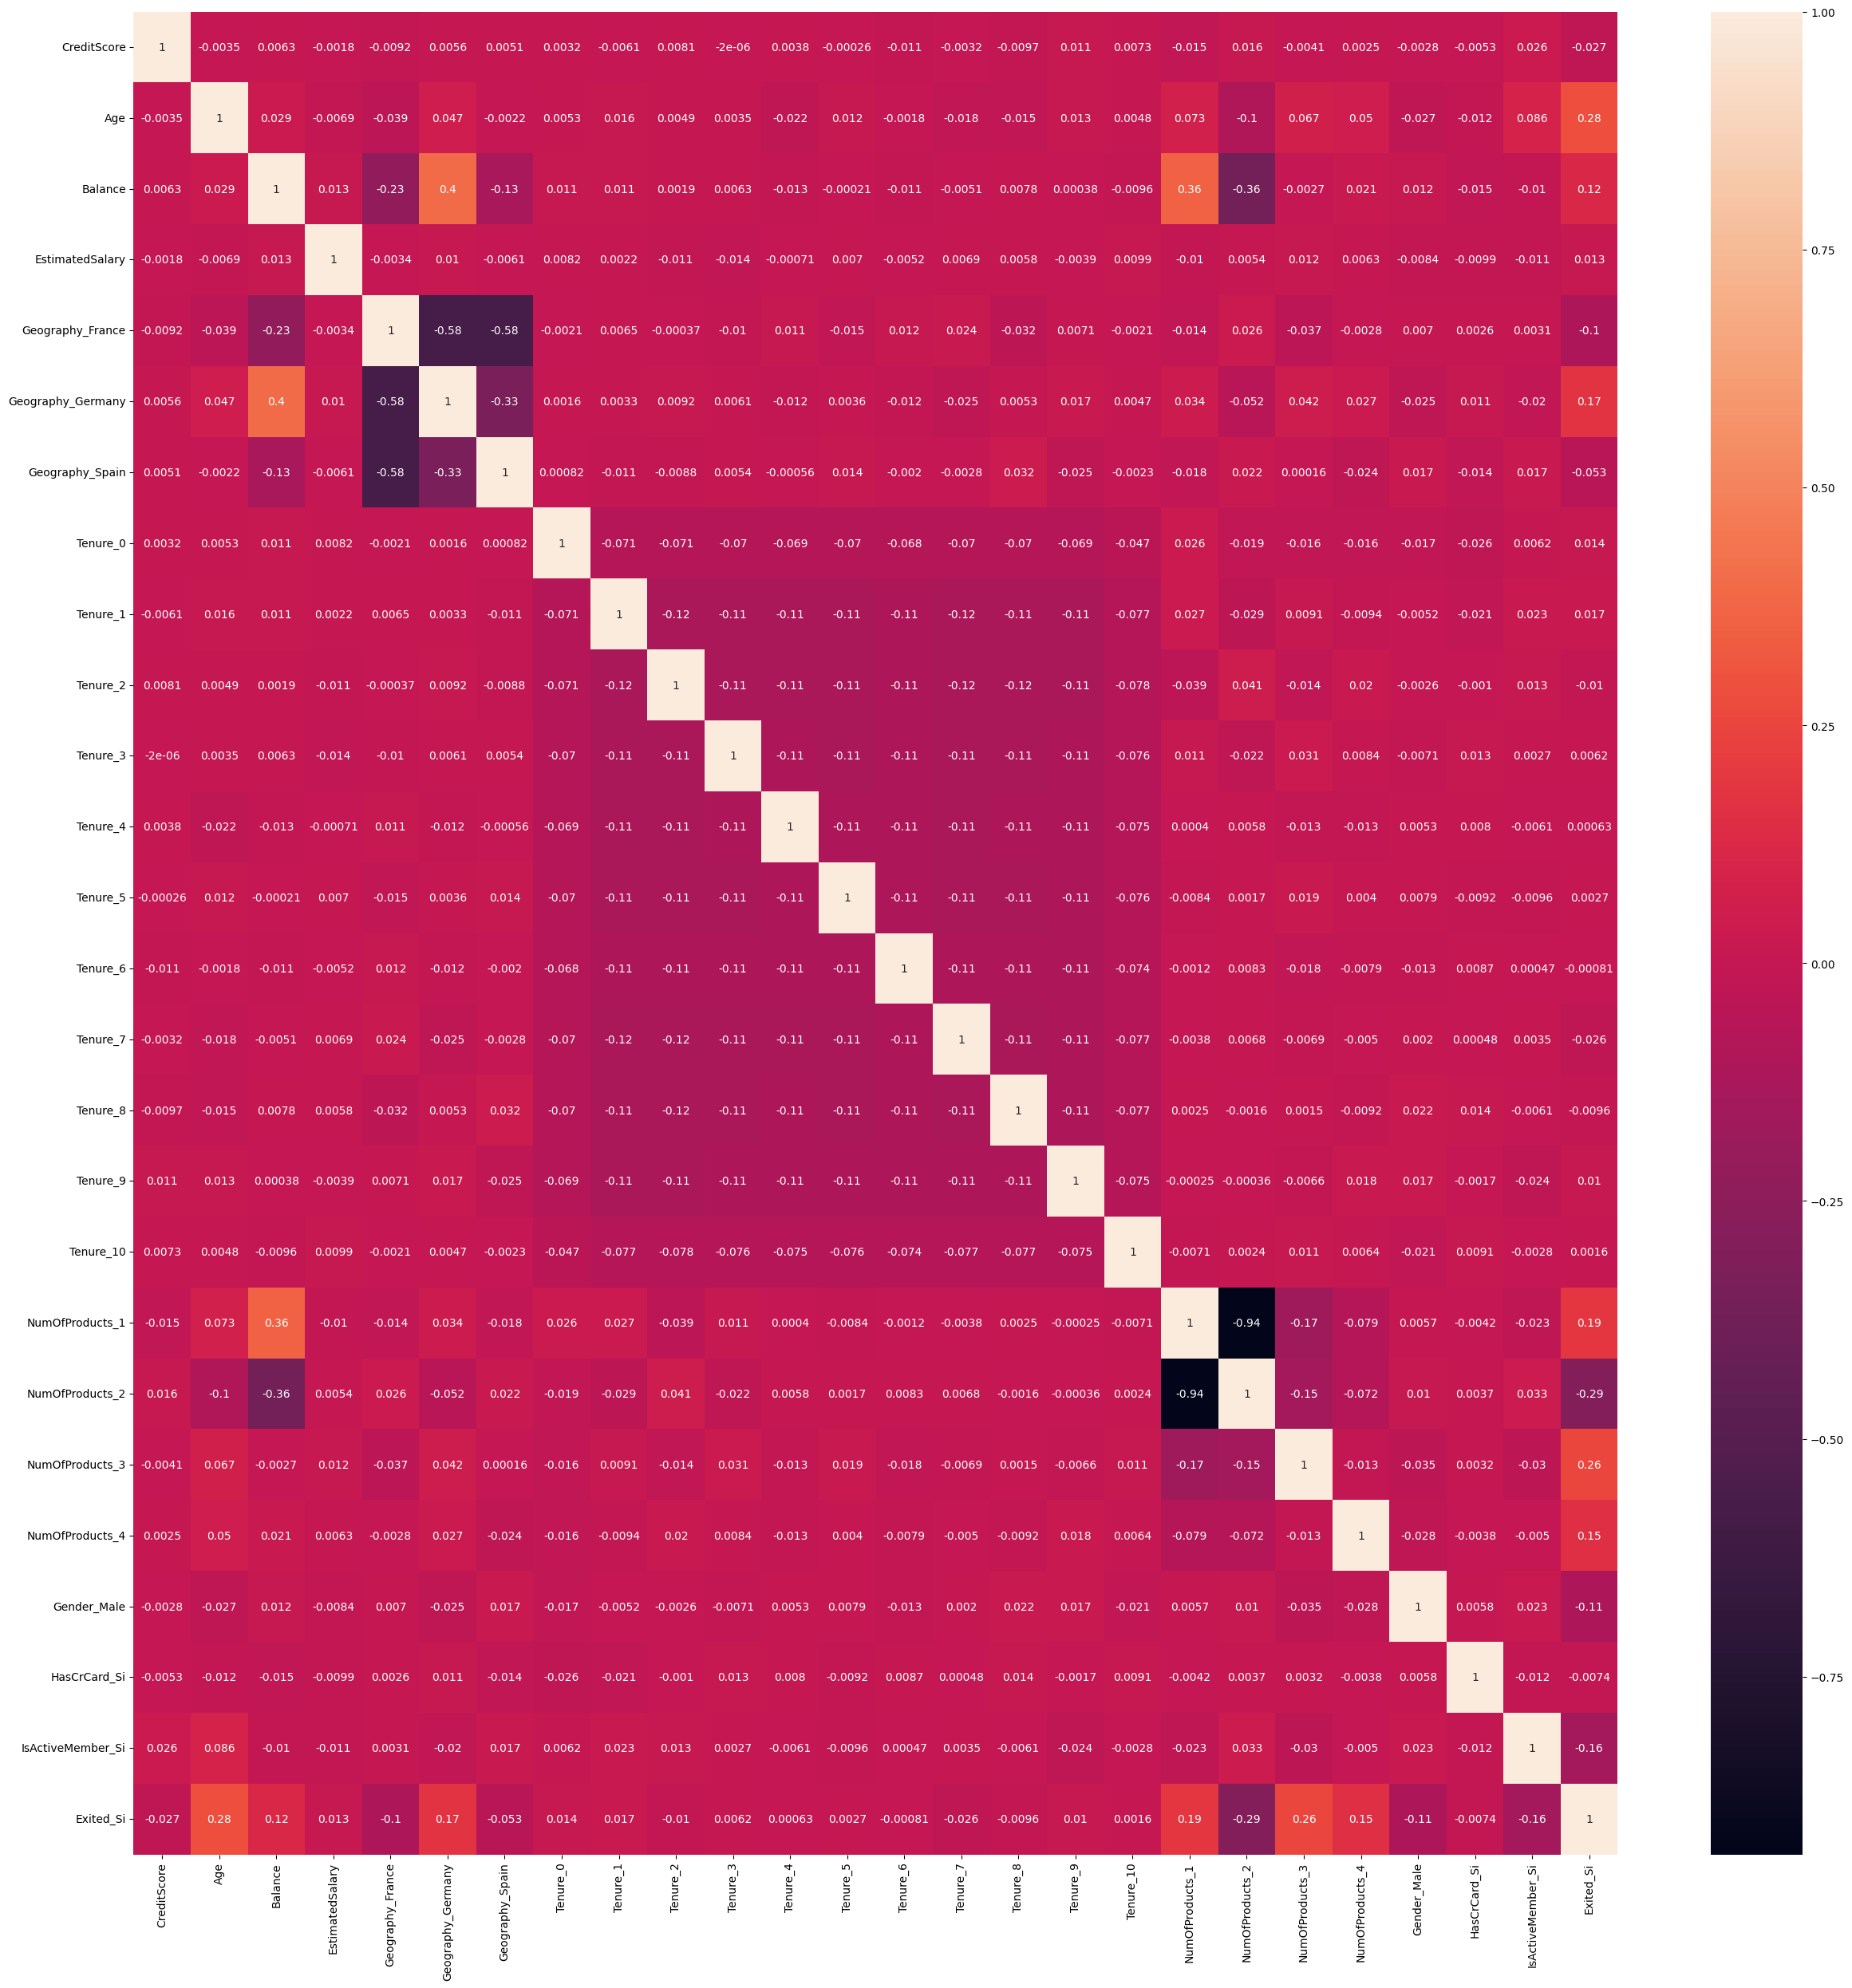

In [138]:
import seaborn as sns
plt.figure(figsize=(30,30))
sns.heatmap(data_num.corr(),annot=True)

In [ ]:
data.corr.info

In [140]:
# Calcular las correlaciones de todas las variables numéricas con la variable objetivo
correlaciones = data_num.corr(numeric_only=True)['Exited_Si'].sort_values(ascending=False)

# Mostrar todas las correlaciones
print(correlaciones)

# Filtrar variables irrelevantes (correlación muy baja)
irrelevantes = correlaciones[abs(correlaciones) < 0.05]
print("\n🔹 Variables con correlación baja (< 0.05) con la variable objetivo:\n")
print(irrelevantes)

Exited_Si            1.000000
Age                  0.284921
NumOfProducts_3      0.255931
NumOfProducts_1      0.185179
Geography_Germany    0.173846
NumOfProducts_4      0.153652
Balance              0.118857
Tenure_1             0.017277
Tenure_0             0.013579
EstimatedSalary      0.012531
Tenure_9             0.010487
Tenure_3             0.006172
Tenure_5             0.002705
Tenure_10            0.001612
Tenure_4             0.000635
Tenure_6            -0.000807
HasCrCard_Si        -0.007393
Tenure_8            -0.009641
Tenure_2            -0.010102
Tenure_7            -0.026483
CreditScore         -0.026758
Geography_Spain     -0.053122
Geography_France    -0.104853
Gender_Male         -0.106305
IsActiveMember_Si   -0.156151
NumOfProducts_2     -0.292259
Name: Exited_Si, dtype: float64

🔹 Variables con correlación baja (< 0.05) con la variable objetivo:

Tenure_1           0.017277
Tenure_0           0.013579
EstimatedSalary    0.012531
Tenure_9           0.010487
Tenure

In [141]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42.0,2,0.00,1,Si,Si,101348.88,Si
1,608,Spain,Female,41.0,1,83807.86,1,No,Si,112542.58,No
2,502,France,Female,42.0,8,159660.80,3,Si,No,113931.57,Si
3,699,France,Female,39.0,1,0.00,2,No,No,93826.63,No
4,850,Spain,Female,43.0,2,125510.82,1,Si,Si,79084.10,No


In [142]:
# Elimino Tenure, EstimatedSalary, HasCrCard_si y CreditScore de data
data = data.drop(['Tenure', 'EstimatedSalary', 'HasCrCard', 'CreditScore'], axis=1) # axis=1 indica que es una columna
data.head()

,Geography,Gender,Age,Balance,NumOfProducts,IsActiveMember,Exited
0,France,Female,42.0,0.00,1,Si,Si
1,Spain,Female,41.0,83807.86,1,Si,No
2,France,Female,42.0,159660.80,3,No,Si
3,France,Female,39.0,0.00,2,No,No
4,Spain,Female,43.0,125510.82,1,Si,No


**2. Balanceo de datos (Clasificación)**

/tmp/ipython-input-3347206687.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(data["Exited"]).plot(kind="bar")


<Axes: xlabel='Exited'>

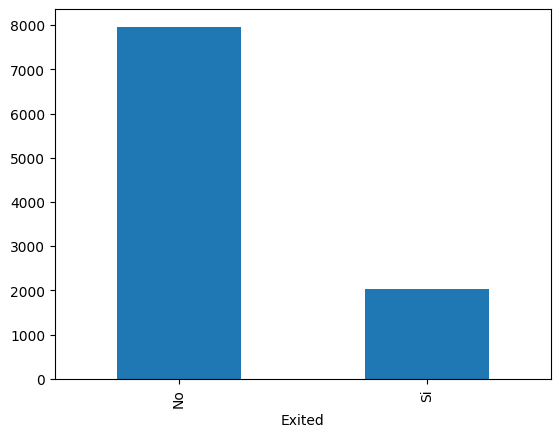

In [143]:
#Variable objetivo
pd.value_counts(data["Exited"]).plot(kind="bar")

In [144]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9996 entries, 0 to 9997
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Geography       9996 non-null   category
 1   Gender          9996 non-null   category
 2   Age             9996 non-null   float64 
 3   Balance         9996 non-null   float64 
 4   NumOfProducts   9996 non-null   category
 5   IsActiveMember  9996 non-null   category
 6   Exited          9996 non-null   category
dtypes: category(5), float64(2)
memory usage: 283.8 KB


In [145]:
from imblearn.over_sampling import SMOTE, SMOTENC

#sm = SMOTE( k_neighbors=2) para variables predictoras numéricas
#sm = SMOTENC(categorical_features=[], k_neighbors=2) para variables predictoras categóricas

sm = SMOTENC(categorical_features=[0,1,3,4,5], k_neighbors=2) #se indican las variables predictoras categoricas
X= data.drop('Exited', axis=1) #Predictoras
Y= data['Exited'] #Objetivo
X_bal, Y_bal = sm.fit_resample(X,Y) #X= variables predictoras Y=variable objetivo

<Axes: xlabel='Exited'>

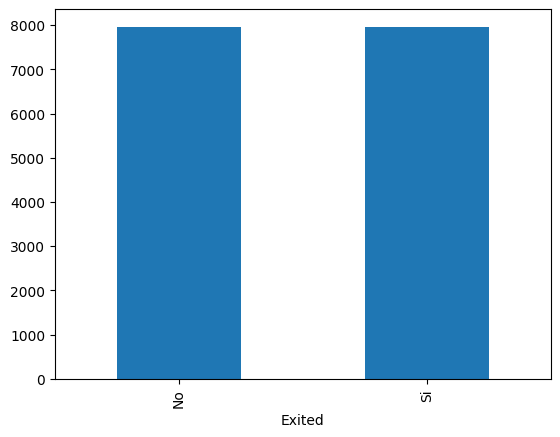

In [146]:
# Creamos un dataframe con los resultados
data  = pd.DataFrame(columns=X.columns.values, data=X_bal)
data['Exited']=Y_bal
data['Exited'].value_counts().plot(kind='bar')

In [147]:
#Guardamos los datos numericos preparados
data_num.to_excel('./datos_numéricos.xlsx')

In [148]:
#Guardamos los datos preparadps
data.to_excel('./datos_P_Churn_Modelling.xlsx')